# **Building AI Agents with LangGraph**

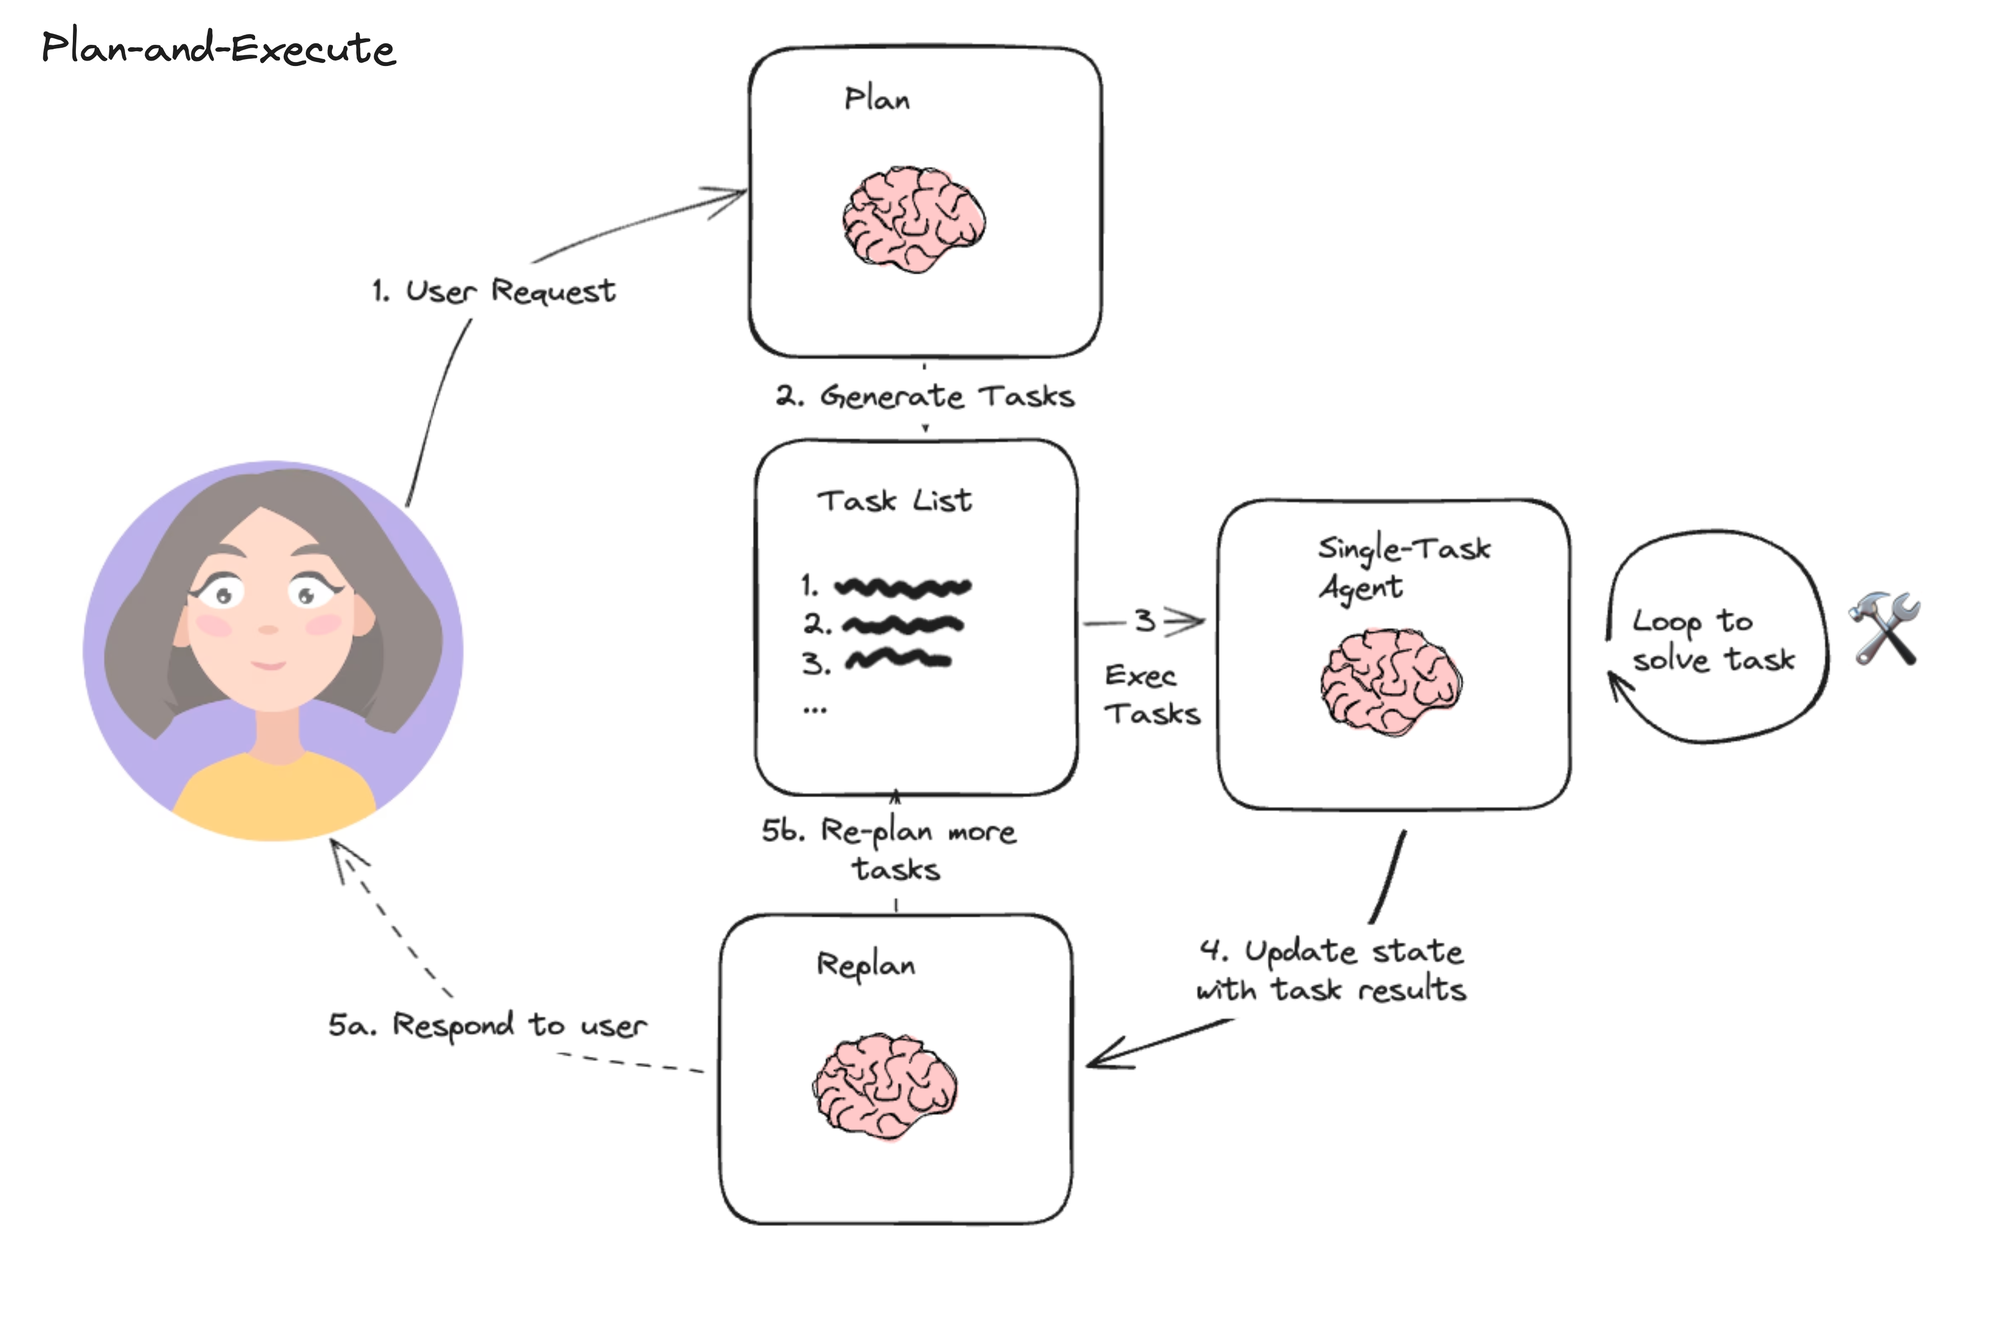

### **LangGraph**

LangGraph is an extension of the LangChain ecosystem that introduces a novel approach to creating AI agent runtimes. At its core, LangGraph allows developers to represent complex workflows as cyclical graphs, providing a more intuitive and flexible way to design agent behaviors.

Using **LangGraph** (or similar graph-based workflow tools), you can design a flexible and extensible workflow that supports customer interaction management.
- **Features of LangGraph**:
  - Visual representation of workflows as nodes and edges.
  - Dynamic branching based on real-time decisions like query type or sentiment score.
  - Easy integration with state management and response systems.
- **Benefits**:
  - Simplifies complex workflows by modularizing processes.
  - Enables rapid updates or modifications to workflows.
  - Scales efficiently with additional features or query types.



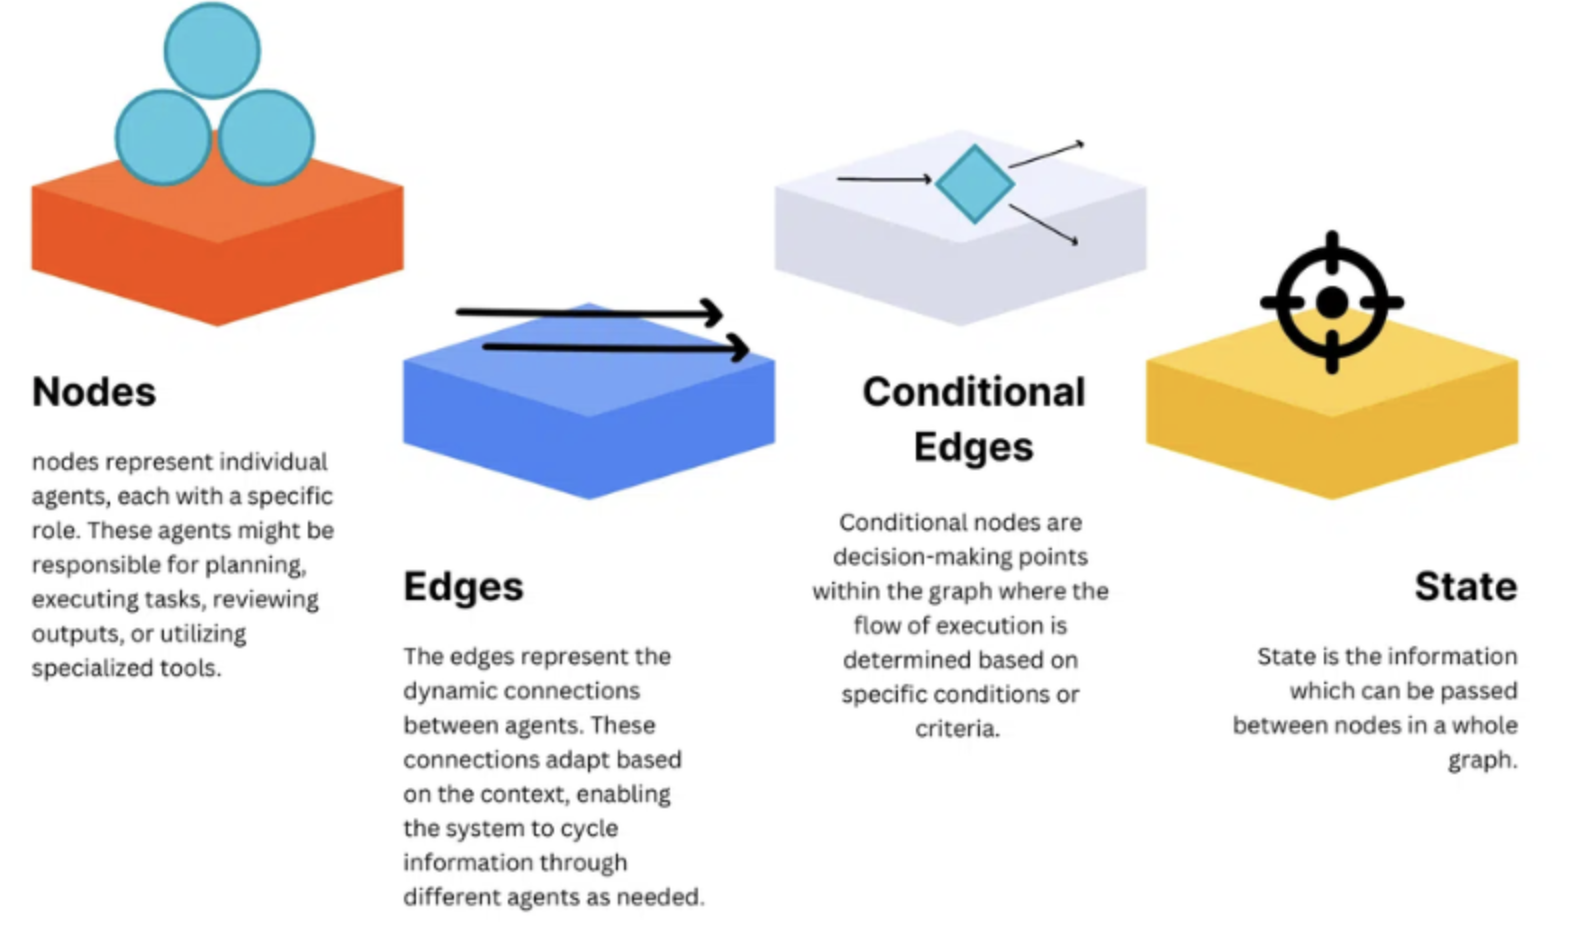

 **The method details for the outlined process:**

**1. Initialization**

In this step, the environment is prepared, and necessary libraries are imported to enable the smooth functioning of the workflow.

**2. State Definition**

Define a structured format to store all relevant details about a customer query, ensuring consistent and type-safe data handling.

**3. Node Functions**

Implement modular functions for each key operation, ensuring reusability and clarity.

***Categorization***:

  Takes a query as input and outputs its category.

***Sentiment Analysis:***

   Determines the emotional tone of the query.

***Response Generation:***

Creates an appropriate response based on the query's category and sentiment.

**4. Graph Construction**

Construct a workflow graph using StateGraph (or an equivalent tool) to represent the customer support process as a series of nodes and edges.

  Steps:

  Define nodes for operations like categorization, sentiment analysis, response generation, and escalation.
Create edges that define the flow of data between these nodes.


**5. Conditional Routing**

Implement logic within the graph to route queries dynamically based on their category or sentiment.

Example: Route queries with negative sentiment to an escalation node

**6. Workflow Compilation**

Transform the constructed graph into an executable format that can process real-time inputs.

Compiling: Use built-in compilation methods of the workflow library to validate and finalize the graph.

**7. Execution**

Process customer queries through the compiled workflow, managing data updates and retrieving results dynamically.

Processing: Each query goes through the workflow, with the state updated at every node.

This method provides a clear, modular, and scalable approach to handling customer support queries, enabling both automated processing and seamless escalation when needed.


### **Key Features**

#### **Powered by Advanced LLM:**
This customer support agent leverages **llama-3.3-70b-versatile**, a state-of-the-art language model with 70 billion parameters. The model is accessed using the **versatile API key** to ensure:
- High-quality language understanding.
- Accurate sentiment and query categorization.
- Seamless response generation.

---

### **Implementation**

#### **llama Integration**
The intelligent processing of customer queries is driven by **llama 3.0**, a robust language model boasting 70 billion parameters. This model, accessed via the **versatile API key**, enables:
1. Precise categorization of queries.
2. Nuanced sentiment analysis.
3. Context-aware and empathetic response generation.

The following code snippet demonstrates the API key configuration:
```python
from langchain_groq import ChatGroq

llm = ChatGroq(
    temperature=0,
    groq_api_key="API_KEY",
    model_name="llama-3.3-70b-versatile"
)
```

This integration ensures that the agent delivers high performance and adaptability to diverse customer queries.

In [ ]:
!pip install langchain langchain_core langchain_core langchain_groq langchain_community langgraph


INFO: pip is looking at multiple versions of langchain-groq to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of langchain-community to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of langgraph-prebuilt to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of langgraph-prebuilt to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.4/155.4 kB

In [ ]:
from typing import TypedDict, Dict
from langgraph.graph import StateGraph, END
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables.graph import MermaidDrawMethod
from IPython.display import display , Image


**State Structure**

In [ ]:
class State(TypedDict):
    query: str
    category: str
    sentiment: str
    response: str

In [ ]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    temperature=0,
    groq_api_key = "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",
    model_name = "llama-3.3-70b-versatile"
)
result = llm.invoke("What is langchain?")
result.content

'LangChain is an open-source framework designed to help developers build applications that utilize large language models (LLMs) more efficiently. It was created to simplify the process of integrating LLMs into various projects, allowing developers to focus on building their applications rather than worrying about the underlying infrastructure.\n\nLangChain provides a set of tools and libraries that enable developers to:\n\n1. **Interact with LLMs**: LangChain offers a unified interface to interact with different LLMs, such as LLaMA, PaLM, and others, making it easier to switch between models or use multiple models in a single application.\n2. **Manage memory and caching**: LangChain includes features to manage memory and caching, which helps to reduce the computational resources required to run LLMs and improves overall performance.\n3. **Implement indexing and retrieval**: LangChain provides tools for indexing and retrieving information from LLMs, making it easier to build application

Define Node Functions

In [ ]:
# --- Node Functions ---
# Each function represents a "node" in our agent graph.
# It receives the current state, performs an action, and returns a dictionary
# with the fields it wants to update in the state.

def categorize(state: State) -> State:
  """
  Categorizes the customer query into 'Technical', 'Billing', or 'General'.
  This is the first processing step.
  """
  print("---CATEGORIZING QUERY---")
  # Docstring providing the node's simple description
  "Technical, Billing, General"

  # Create a prompt template to instruct the LLM
  prompt = ChatPromptTemplate.from_template(
      "Categorize the following customer query into one of these categories: "
      "Technical, Billing, General. Query: {query}"
  )

  # Create an LLM "chain" by piping the prompt to the model
  chain = prompt | llm

  # Invoke the chain, passing in the query from the current state
  category = chain.invoke({"query": state["query"]}).content

  # Return a dictionary with the updated 'category' field
  return {"category": category}

def analyze_sentiment(state: State) -> State:
  """
  Analyzes the sentiment of the customer query, returning 'Positive', 'Negative', or 'Neutral'.
  """
  print("---ANALYZING SENTIMENT---")
  # Create a prompt template for sentiment analysis
  prompt = ChatPromptTemplate.from_template(
      "Analyze the sentiment of the following customer query: {query}"
      "Response with either 'Positive', 'Negative', or 'Neutral'. Query: {query}"
  )

  # Create the chain
  chain = prompt | llm

  # Invoke the chain with the query
  sentiment = chain.invoke({"query": state["query"]}).content

  # Return the updated 'sentiment' field
  return {"sentiment": sentiment}

def handle_technical(state: State) -> State:
  """
  Generates a specific response for technical queries.
  """
  print("---HANDLING TECHNICAL QUERY---")
  # Prompt template for generating a technical support response
  prompt = ChatPromptTemplate.from_template(
      "Provide a technical response to the following customer query: {query}"
  )
  chain = prompt | llm
  response = chain.invoke({"query": state["query"]}).content

  # Return the generated 'response'
  return {"response": response}


def handle_billing(state: State) -> State:
  """
  Generates a specific response for billing queries.
  """
  print("---HANDLING BILLING QUERY---")
  # Prompt template for generating a billing support response
  prompt = ChatPromptTemplate.from_template(
      "Provide a billing response to the following customer query: {query}"
  )
  chain = prompt | llm
  response = chain.invoke({"query": state["query"]}).content

  # Return the generated 'response'
  return {"response": response}

def handle_general(state: State) -> State:
  """
  Generates a response for general queries.
  """
  print("---HANDLING GENERAL QUERY---")
  # Prompt template for generating a general support response
  prompt = ChatPromptTemplate.from_template(
      "Provide a general response to the following customer query: {query}"
  )
  chain = prompt | llm
  response = chain.invoke({"query": state["query"]}).content

  # Return the generated 'response'
  return {"response": response}

def escalate(state: State) -> State:
  """
  Provides a response indicating the query is being escalated.
  This node doesn't call an LLM.
  """
  print("---ESCALATING QUERY---")
  # Return a static 'response' indicating escalation
  return {"response": "This query has been escalated to a human agent due to its negative sentiment."} # Typo 'sentimant' corrected

# --- Conditional Routing Function ---
# This function acts as the "brain" or "router" for the graph.
# It inspects the state and decides which node to go to next.

def route_query(state: State) -> str:
  """
  Reads the 'sentiment' and 'category' from the state and returns
  the name of the next node to execute.
  """
  print("---ROUTING QUERY---")
  # First, check for negative sentiment to escalate immediately
  if "Negative" in state["sentiment"]: # Made check more robust
    return "escalate"
  # If not negative, route based on category
  elif "Technical" in state["category"]: # Made check more robust
    return "handle_technical"
  elif "Billing" in state["category"]: # Made check more robust
    return "handle_billing"
  else:
    return "handle_general"

Configure Graph

In [ ]:
# --- Graph Construction ---
# This is where we define the structure of our agent's workflow.

# 1. Initialize the StateGraph
# We create a new graph instance, telling it to use our 'State' class (TypedDict)
# as its central "state" or memory object.
workflow = StateGraph(State)

# 2. Add Nodes
# Each node is a "step" in the workflow, defined by a name (string) and
# the function it should execute when called.
workflow.add_node("categorize", categorize)
workflow.add_node("analyze_sentiment", analyze_sentiment)
workflow.add_node("handle_technical", handle_technical)
workflow.add_node("handle_billing", handle_billing)
workflow.add_node("handle_general", handle_general)
workflow.add_node("escalate", escalate)

# 3. Add Edges (Connections)
# Edges define the path from one node to the next.

# 3a. Add a standard edge
# This creates a fixed, unconditional link. After 'categorize' is done,
# the workflow will ALWAYS move to 'analyze_sentiment'.
workflow.add_edge("categorize", "analyze_sentiment")

# 3b. Add conditional edges
# This is the "brain" of the agent. It creates a decision point.
workflow.add_conditional_edges(
    # The decision is made AFTER the 'analyze_sentiment' node runs.
    "analyze_sentiment",
    # The 'route_query' function is called to make the decision.
    # This function will inspect the state and return a string (e.g., "escalate").
    route_query,
    # This dictionary maps the string returned by 'route_query' to the
    # next node that should be executed.
    {
        "handle_technical" : "handle_technical",
        "handle_billing" : "handle_billing",
        "handle_general" : "handle_general",
        "escalate" : "escalate"
    }
)

# 3c. Add edges to the END
# These nodes are terminal. After they run, the graph finishes.
# 'END' is a special constant that tells LangGraph to stop execution.
workflow.add_edge("handle_technical", END)
workflow.add_edge("handle_billing", END)
workflow.add_edge("handle_general", END)
workflow.add_edge("escalate", END)

# 4. Set the Entry Point
# This tells the graph which node to run first.
workflow.set_entry_point("categorize")

# 5. Compile the Graph
# This finalizes the graph and creates a runnable 'app' (an instance of LangChain's
# Runnable interface) that we can .invoke() with our input.
app = workflow.compile()

visualise the graph

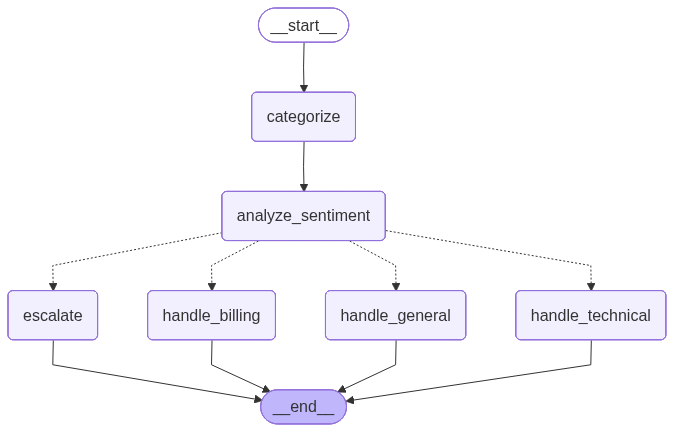

In [ ]:
display(
    Image(
        app.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API
        )
    )
)


###**State Management**
State management is crucial for keeping track of the status of customer interactions. Using **TypedDict**, a feature in Python's `typing` module, you can define a structured and type-safe representation of the interaction state. This ensures consistency and clarity in managing data.

By utilizing TypedDict, developers can enforce the expected structure of the state at compile-time, reducing runtime errors and improving maintainability.

---

### **Query Categorization**
Categorizing customer queries into predefined types such as **Technical**, **Billing**, and **General** allows for targeted responses and streamlined workflow management.
- **Technical queries**: Issues related to software, hardware, or service configurations.
- **Billing queries**: Questions regarding invoices, payments, refunds, or subscription plans.
- **General queries**: Inquiries that do not fall under technical or billing, such as operational hours or company policies.

Machine learning models or rule-based systems can be employed for classification. Pretrained Natural Language Processing (NLP) tools or custom classifiers fine-tuned on historical customer data can automate this categorization effectively.

---

### **Sentiment Analysis**
Sentiment analysis evaluates the emotional tone of customer interactions, identifying whether the sentiment is **positive**, **neutral**, or **negative**.
- **Purpose**:
  - Prioritize addressing negative sentiments.
  - Enhance customer experience by tailoring responses.
  - Detect underlying frustration or dissatisfaction early.
---

### **Response Generation**
Based on the categorized query and sentiment, automated response generation provides appropriate and empathetic replies to customer queries.
- **Factors in response generation**:
  - **Query type**: Responses vary for technical, billing, or general inquiries.
  - **Sentiment**: Negative sentiment prompts more empathetic and apologetic language.
  - **History**: Prior interactions influence the response to ensure continuity and relevance.
- **Tools**: Natural Language Generation (NLG) libraries like OpenAI's GPT models or template-based response systems can be employed to craft these responses dynamically.

Customer support function

In [ ]:
def run_customer_support(query: str) -> str:
  results = app.invoke({"query": query})
  return {
      "category":results["category"],
      "sentiment": results["sentiment"],
      "response": results["response"]
  }

In [ ]:
query = "I can't access my account"
result = run_customer_support(query)
print (f"Query:  {query}")
print (f"Category: {result['category']}")
print (f"Sentiment: {result['sentiment']}")
print (f"Response: {result['response']}")
print("\n")

---CATEGORIZING QUERY---
---ANALYZING SENTIMENT---
---ROUTING QUERY---
---ESCALATING QUERY---
Query:  I can't access my account
Category: I would categorize the query "I can't access my account" as Technical. This is because the issue is related to a functional problem with accessing the account, which typically requires technical support to resolve.
Sentiment: Negative.
Response: This query has been escalated to a human agent due to its negative sentiment.




In [ ]:
query = "I forget my password"
result = run_customer_support(query)
print (f"Query:  {query}")
print (f"Category: {result['category']}")
print (f"Sentiment: {result['sentiment']}")
print (f"Response: {result['response']}")
print("\n")

---CATEGORIZING QUERY---
---ANALYZING SENTIMENT---
---ROUTING QUERY---
---HANDLING TECHNICAL QUERY---
Query:  I forget my password
Category: The customer query "I forget my password" would be categorized as "Technical" since it involves a technical issue with account access.
Sentiment: Neutral. The customer is simply stating a fact about forgetting their password, without expressing any emotion or sentiment.
Response: **Password Recovery Procedure**

Dear valued customer,

We apologize for the inconvenience you're experiencing with forgetting your password. To assist you in regaining access to your account, we've outlined the steps to follow:

### Step 1: Access the Login Page
Navigate to the login page of our website or application. Click on the "Forgot Password" link, usually located below the login form.

### Step 2: Enter Your Username or Email
Enter your registered username or email address associated with your account in the provided field. This will initiate the password recover

In [ ]:
query = " Where can I find my receipt"
result = run_customer_support(query)
print (f"Query:  {query}")
print (f"Category: {result['category']}")
print (f"Sentiment: {result['sentiment']}")
print (f"Response: {result['response']}")
print("\n")

---CATEGORIZING QUERY---
---ANALYZING SENTIMENT---
---ROUTING QUERY---
---HANDLING BILLING QUERY---
Query:   Where can I find my receipt
Category: I would categorize the customer query "Where can I find my receipt" into the category of "Billing". This is because the query is related to a financial transaction and the customer is looking for documentation of their payment.
Sentiment: Neutral. The customer is simply asking a question about the location of their receipt, without expressing any emotion or sentiment. There is no language indicating satisfaction, dissatisfaction, or frustration, so the sentiment is neutral.
Response: Dear valued customer,

Thank you for reaching out to us regarding your receipt. We apologize for any inconvenience you may have experienced in locating it.

To access your receipt, you can try the following options:

1. **Check your email**: If you provided an email address during the checkout process, your receipt should have been sent to you via email. Please 

In [ ]:
!pip install gradio

In [ ]:
import gradio as gr

# Create the Gradio interface
def gradio_interface(query: str) -> str:
  result = run_customer_support(query)
  return (
      f"**Category:** {result['category']}<br><br>"
      f"**Sentiment:** {result['sentiment']}<br><br>\n"
      f"**Response:** {result['response']}"
  )

# Build the gradio app
iface = gr.Interface(
    fn=gradio_interface,
    inputs=gr.Textbox(lines=2, placeholder="Enter your query here..."),
    outputs="markdown",
    title="I'm your Customer Support Assistant",
    description="Provide your query.",
)

# Lanuch the app
iface.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e557a123203e5eb971.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Next step

1. Add external knowledge with the help of RAG
2. Use https://www.kaggle.com/datasets/suraj520/customer-support-ticket-dataset dataset
